In [1]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
max_degree = 20  # 多项式的最大阶数
n_train, n_test = 100, 100  # 训练和测试数据集大小
true_w = np.zeros(max_degree)  # 分配大量的空间
print(true_w)
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])
print(true_w)



[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 5.   1.2 -3.4  5.6  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0. ]


In [3]:
features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # gamma(n)=(n-1)!
# labels的维度:(n_train+n_test,)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

In [4]:
# NumPy ndarray转换为tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=
    torch.float32) for x in [true_w, features, poly_features, labels]]

features[:2], poly_features[:2, :], labels[:2]

(tensor([[-0.3360],
         [-0.2651]]),
 tensor([[ 1.0000e+00, -3.3599e-01,  5.6446e-02, -6.3218e-03,  5.3102e-04,
          -3.5684e-05,  1.9983e-06, -9.5916e-08,  4.0284e-09, -1.5039e-10,
           5.0530e-12, -1.5434e-13,  4.3216e-15, -1.1169e-16,  2.6806e-18,
          -6.0044e-20,  1.2609e-21, -2.4921e-23,  4.6518e-25, -8.2263e-27],
         [ 1.0000e+00, -2.6514e-01,  3.5148e-02, -3.1064e-03,  2.0590e-04,
          -1.0918e-05,  4.8248e-07, -1.8274e-08,  6.0565e-10, -1.7842e-11,
           4.7306e-13, -1.1402e-14,  2.5193e-16, -5.1381e-18,  9.7307e-20,
          -1.7200e-21,  2.8501e-23, -4.4452e-25,  6.5476e-27, -9.1368e-29]]),
 tensor([4.4995, 4.5867]))

In [7]:
a,b = 5,3
features = np.random.normal(size=(a, b))
print(features)
np.random.shuffle(features)
print("after shuffle:")
print(features)


[[-1.43852072 -1.01601899 -0.00900025]
 [-0.45099713  0.15738514  0.97138716]
 [-1.53967687 -0.66345245  1.65379998]
 [ 0.71267595  0.08272314  0.62631693]
 [ 0.90235254  0.36476059 -0.54411756]]
after shuffle:
[[-1.43852072 -1.01601899 -0.00900025]
 [ 0.71267595  0.08272314  0.62631693]
 [ 0.90235254  0.36476059 -0.54411756]
 [-0.45099713  0.15738514  0.97138716]
 [-1.53967687 -0.66345245  1.65379998]]


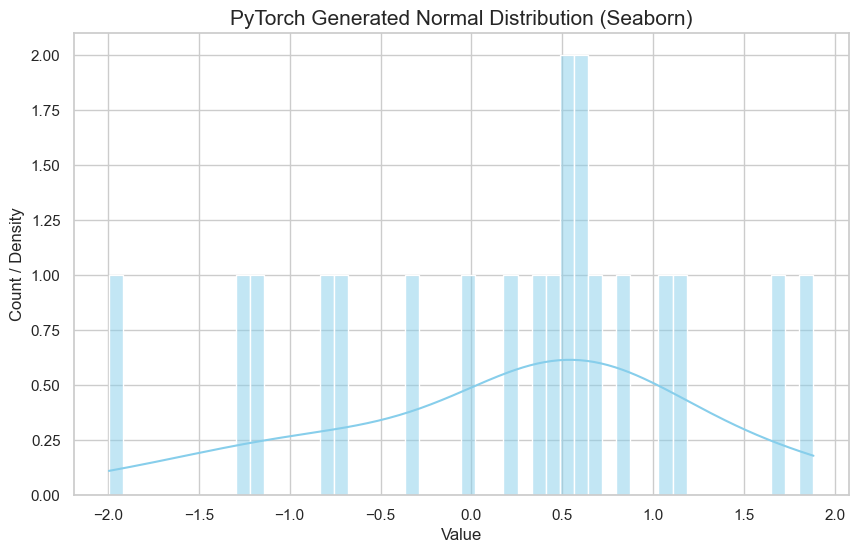

In [9]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 使用 PyTorch 生成正态分布数据
# torch.randn 生成标准正态分布 (均值=0, 标准差=1)
# 生成 10000 个点，数据越多，图形越接近完美的钟形
data_tensor = torch.randn(20)

# 2. 转换数据
# 大多数绘图库不直接支持 PyTorch Tensor，需要转成 Numpy 数组
data_numpy = data_tensor.numpy()

# 3. 设置图形风格 (可选)
sns.set_theme(style="whitegrid")

# 4. 画图
plt.figure(figsize=(10, 6)) # 设置画布大小

# kde=True 表示显示平滑的密度曲线
sns.histplot(data_numpy, kde=True, color="skyblue", bins=50)

plt.title("PyTorch Generated Normal Distribution (Seaborn)", fontsize=15)
plt.xlabel("Value")
plt.ylabel("Count / Density")

# 5. 显示
plt.show()

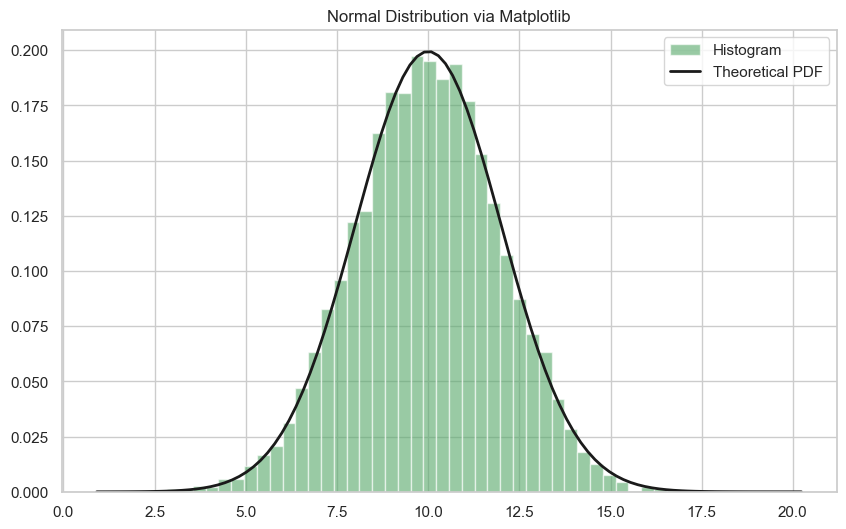

In [10]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. 生成数据
# 这里演示生成自定义均值和标准差的正态分布
# 均值(mean) = 10, 标准差(std) = 2
mean = 10
std = 2
data_tensor = torch.normal(mean=mean, std=std, size=(10000,))

# 2. 转为 Numpy
data_numpy = data_tensor.numpy()

# 3. 画直方图
plt.figure(figsize=(10, 6))

# bins: 柱子的数量
# density: 是否归一化（显示概率密度而不是计数）
# alpha: 透明度
plt.hist(data_numpy, bins=50, density=True, alpha=0.6, color='g', label='Histogram')

# 4. (可选) 手动画出理论上的正态分布曲线做对比
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std)**2)
plt.plot(x, p, 'k', linewidth=2, label='Theoretical PDF')

plt.title("Normal Distribution via Matplotlib")
plt.legend()
plt.show()

Executing Shuffle...


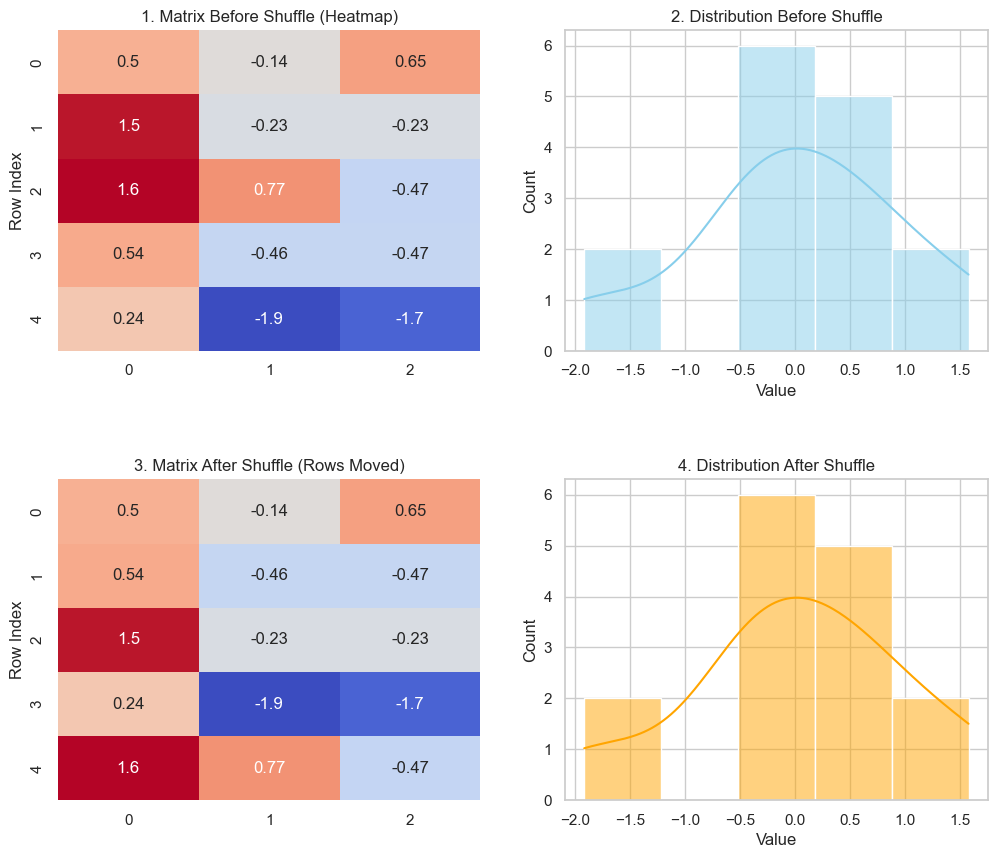

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 准备数据
a, b = 5, 3
# 为了方便对比，我们固定一个随机种子，这样你每次运行结果都一样
np.random.seed(42) 
features = np.random.normal(size=(a, b))

# 设置画布，准备画 2 行 2 列的图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.subplots_adjust(hspace=0.4) # 调整子图间距

# ==========================================
# 第一阶段：打乱前 (Original)
# ==========================================

# 1. 画热力图 (展示矩阵长什么样)
# annot=True 会把具体的数值写在格子里，非常适合数据量小的情况
sns.heatmap(features, annot=True, cmap="coolwarm", cbar=False, ax=axes[0, 0])
axes[0, 0].set_title("1. Matrix Before Shuffle (Heatmap)")
axes[0, 0].set_ylabel("Row Index")

# 2. 画分布图 (尝试看正态分布)
# flatten() 把 (5,3) 的矩阵拉平变成 15 个数，因为统计分布不关心形状
sns.histplot(features.flatten(), kde=True, bins=5, ax=axes[0, 1], color="skyblue")
axes[0, 1].set_title("2. Distribution Before Shuffle")
axes[0, 1].set_xlabel("Value")

# ==========================================
# 第二阶段：执行打乱 (Shuffle)
# ==========================================

print("Executing Shuffle...")
np.random.shuffle(features) # 注意：这只打乱“行”的顺序

# ==========================================
# 第三阶段：打乱后 (After Shuffle)
# ==========================================

# 3. 画热力图 (观察行的变化)
sns.heatmap(features, annot=True, cmap="coolwarm", cbar=False, ax=axes[1, 0])
axes[1, 0].set_title("3. Matrix After Shuffle (Rows Moved)")
axes[1, 0].set_ylabel("Row Index")

# 4. 画分布图 (对比有没有变化)
sns.histplot(features.flatten(), kde=True, bins=5, ax=axes[1, 1], color="orange")
axes[1, 1].set_title("4. Distribution After Shuffle")
axes[1, 1].set_xlabel("Value")

plt.show()